In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from parameterrun import parameterrun

from geodesiq import *

# Ising spin chain (with QuSpin)

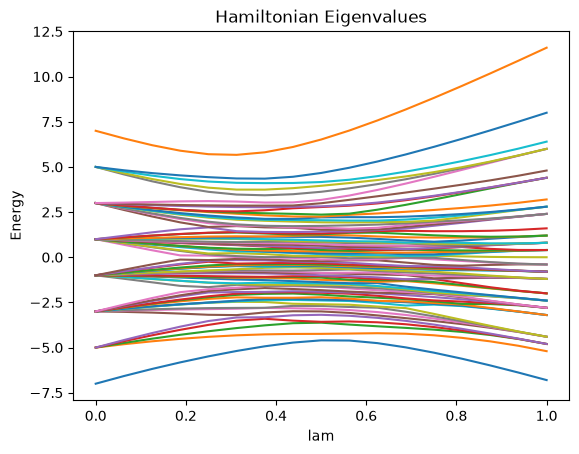

In [9]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian


def ising_model(lam, L, hx, hz):
    """
    Constructs the Ising Hamiltonian with transverse (hx) and longitudinal (hz) fields.
    """
    zz_list = [[lam, i, i + 1] for i in range(L - 1)]
    z_list = [[lam * hz, i] for i in range(L)]
    x_list = [[(1 - lam) * hx, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list], ["x", x_list]]

    basis = spin_basis_1d(L, pblock=1)
    H = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=False, check_herm=False)

    return H.toarray()


ising = Hamiltonian(ising_model)

# ----- Set system and control parameters -----
alpha, beta = 2, 2
initial_state = 0

L, hx, hz = 7, 1, .8
lam0, lamf = 0, 1

ising.set_parameters(L=L, hx=hx, hz=hz)
ising.set_control(control_name='lam', pulse_initial=lam0, pulse_final=lamf, initial_state=initial_state, alpha=alpha, beta=beta,
                  num_steps=2 ** 4 + 1)

ising.plot_eigenvalues(legend=False);

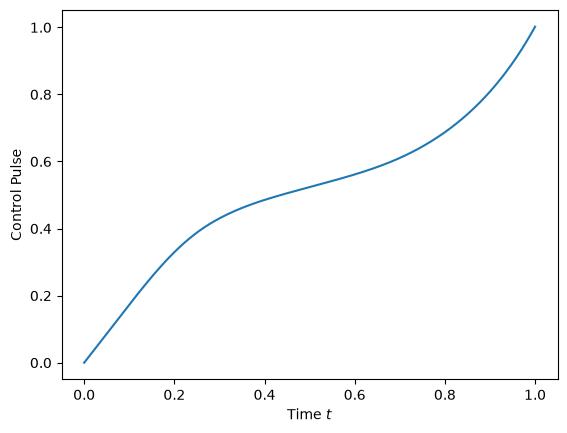

In [10]:
ising.solve_problem(pulse_accuracy=int(100))
ising.synthesize_pulse(duration=1, method='plot');

# Time dependent simulations

In [11]:
def _worker_compute_fidelity(duration, hamiltonian, psi_i, psi_t):
    dynamics = Dynamics(duration=duration, hamiltonian=hamiltonian)
    return dynamics.state_fidelity(initial_state=psi_i, final_state=psi_t)


def fidelity_vs_time(durations, hamiltonian, L, n_jobs=-1):
    hamiltonian.set_parameters(L=L)
    hamiltonian.solve_problem(pulse_accuracy=int(100))

    _, init_eigenstates = qt.Qobj(hamiltonian(lam=lam0)).eigenstates()
    psi_init = init_eigenstates[initial_state]

    _, final_eigenstates = qt.Qobj(hamiltonian(lam=lamf)).eigenstates()
    psi_target = final_eigenstates[initial_state]
    
    # Run the loop in parallel
    # fidelities = Parallel(n_jobs=n_jobs)(
    #     delayed(_worker_compute_fidelity)(duration, hamiltonian) 
    #     for duration in tqdm(durations, desc="Computing fidelities")
    # )

    fidelities = parameterrun(_worker_compute_fidelity, 'duration', durations, hamiltonian=hamiltonian,
                              psi_i=psi_init, psi_t=psi_target, n_workers=n_jobs)

    return np.array(fidelities)

In [12]:
durations = np.linspace(0.1, 1000, 20)
fidelities_L2 = fidelity_vs_time(durations=durations, hamiltonian=ising, L=2)
fidelities_L4 = fidelity_vs_time(durations=durations, hamiltonian=ising, L=4)

_worker_compute_fidelity: [['duration']]:   0%|          | 0/20 [00:00<?, ?it/s]

_worker_compute_fidelity: [['duration']]:   0%|          | 0/20 [00:00<?, ?it/s]

In [13]:
fidelities_L6 = fidelity_vs_time(durations=durations, hamiltonian=ising, L=6)

_worker_compute_fidelity: [['duration']]:   0%|          | 0/20 [00:00<?, ?it/s]

In [11]:
fidelities_L8 = fidelity_vs_time(durations=durations, hamiltonian=ising, L=8)

_worker_compute_fidelity: [['duration']]:   0%|          | 0/20 [00:00<?, ?it/s]

In [12]:
fidelities_L10 = fidelity_vs_time(durations=durations, hamiltonian=ising, L=10)

Computing fidelities:   0%|          | 0/20 [00:00<?, ?it/s]

/mnt/c/Users/vawi76si/OneDrive - Universität Augsburg/Projects/geodesiq-control/src/geodesiq/dynamics.py:115: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your function to the pythonic signature f(t, **kwargs) to maintain compatibility.
  H_T = qt.QobjEvo(self._get_ham, args={"pulse": self._control_sol, "times": self._pulse_times})
/mnt/c/Users/vawi76si/OneDrive - Universität Augsburg/Projects/geodesiq-control/src/geodesiq/dynamics.py:115: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your function to the pythonic signature f(t, **kwargs) to maintain compatibility.
  H_T = qt.QobjEvo(self._get_ham, args={"pulse": self._control_sol, "times": self._pulse_times})
/mnt/c/Users/vawi76si/OneDrive - Universität Augsburg/Projects/geodesiq-control/src/geodesiq/dynamics.py:115: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your f

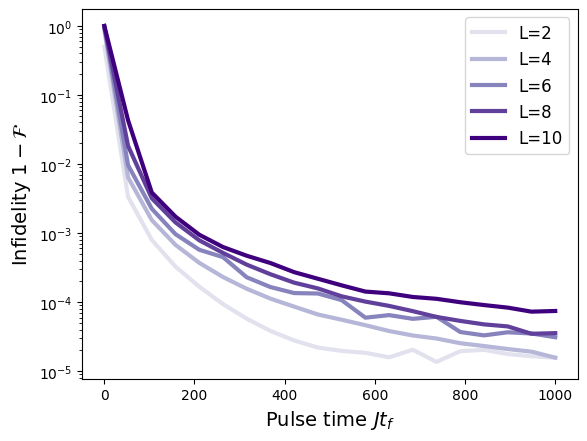

In [14]:
import matplotlib.cm as cm

L_vals = np.array([2, 4, 6, 8, 10])
norm = plt.Normalize(vmin=L_vals.min() - 2, vmax=L_vals.max())
colors_rgba = cm.Purples(norm(L_vals))

data = {'L=2': fidelities_L2, 'L=4': fidelities_L4, 'L=6': fidelities_L6, 'L=8': fidelities_L8, 'L=10': fidelities_L10}

for (label, fidelities) in data.items():
    plt.plot(durations, 1 - fidelities, label=label, lw=3, color=colors_rgba[int(label.split('=')[1]) // 2 - 1])

plt.yscale('log')
plt.ylabel(r'Infidelity $1-\mathcal{F}$', fontsize=14)
plt.xlabel('Pulse time $J t_f$', fontsize=14)
plt.legend(fontsize=12)
plt.show();